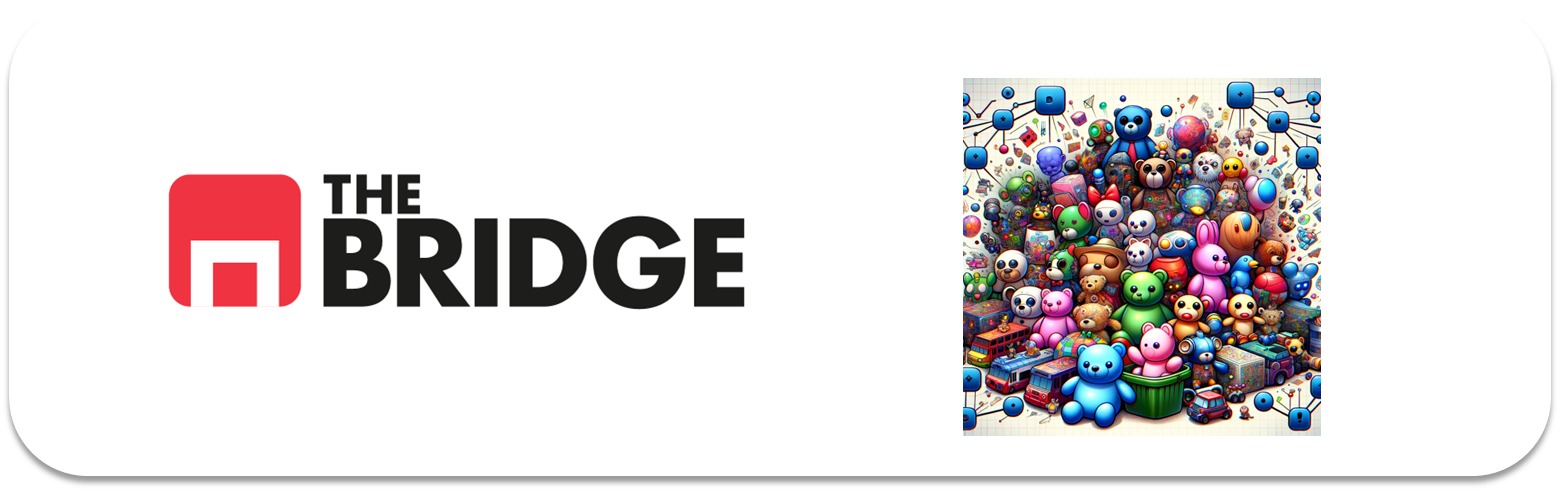

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples, balanced_accuracy_score,
                             accuracy_score, adjusted_rand_score, normalized_mutual_info_score)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from threadpoolctl import threadpool_limits
threadpool_limits(2)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.neighbors import NearestNeighbors

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64

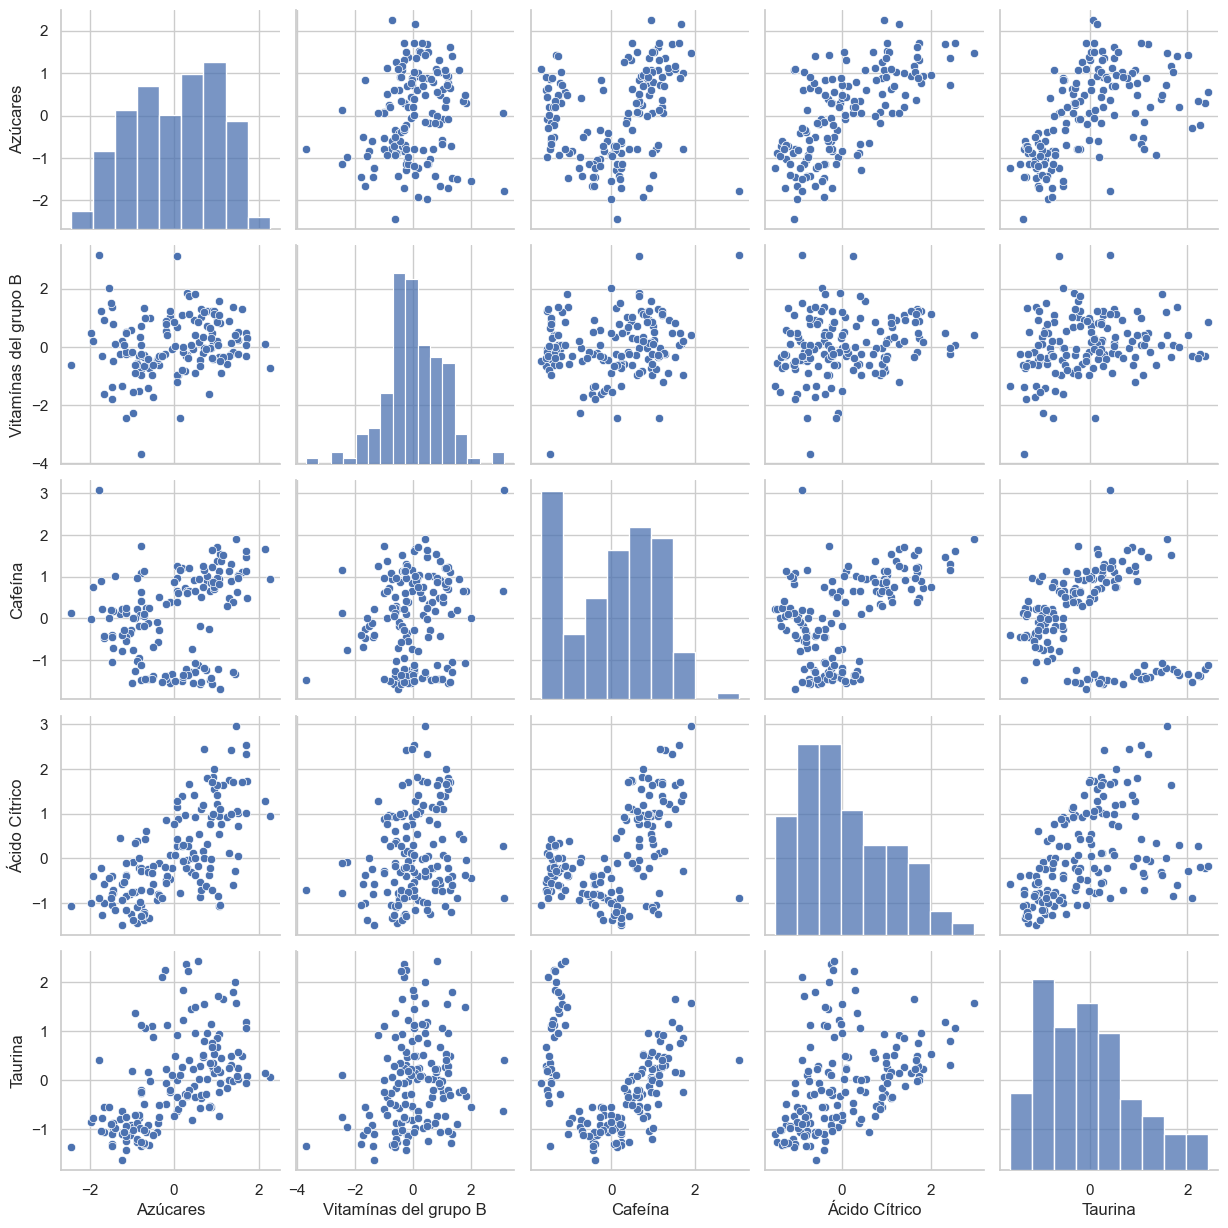

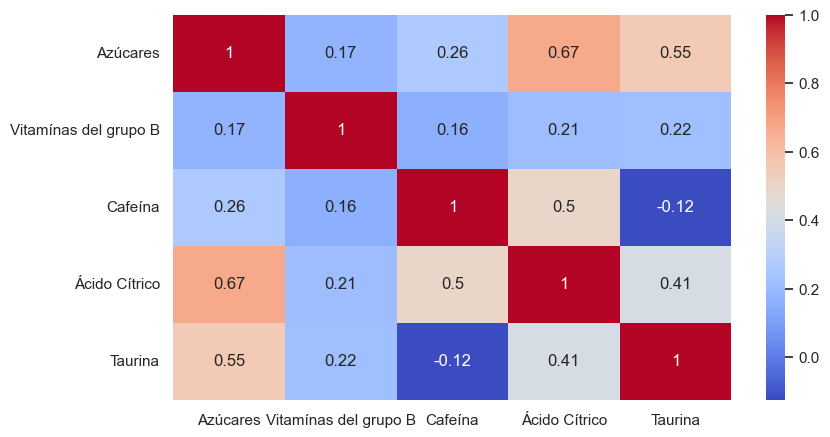

,eps,min_samples,k,ruido,silueta
22,1.026271,4,3,0.111111,0.443394
147,1.225424,10,3,0.117647,0.439110
83,1.066102,6,3,0.117647,0.436625
84,1.105932,6,3,0.098039,0.424099


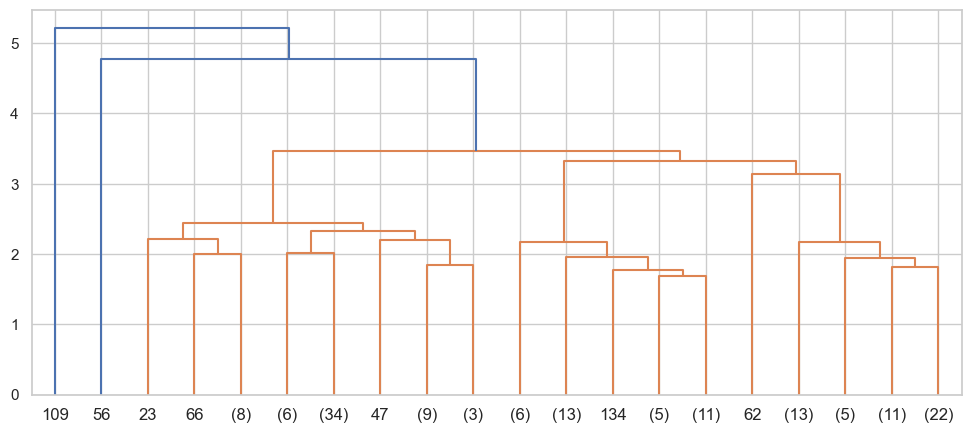

3    0.296189
4    0.280008
5    0.366557
Name: silueta_jerarquico, dtype: float64

,modelo,k,silueta,cobertura
0,DBSCAN,3,0.443394,0.888889
1,Jerárquico,5,0.366557,1.000000


Azúcares       Vitamínas del grupo B         Cafeína        \
             mean count                  mean count      mean count   
cluster                                                               
-1      -0.038548    17             -0.236691    17  0.290702    17   
 0       0.914705    54              0.353897    54  0.959521    54   
 1      -1.083422    48             -0.329195    48 -0.074773    48   
 2       0.182581    34              0.188749    34 -1.378977    34   

        Ácido Cítrico         Taurina        
                 mean count      mean count  
cluster                                      
-1           0.012516    17 -0.074746    17  
 0           1.159260    54  0.182025    54  
 1          -0.811573    48 -0.983721    48  
 2          -0.341587    34  0.938663    34

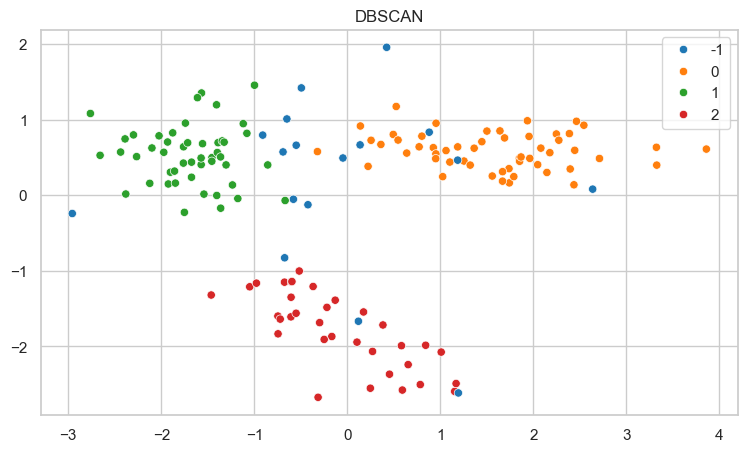

Azúcares       Vitamínas del grupo B         Cafeína        \
             mean count                  mean count      mean count   
cluster                                                               
0       -1.057628    52             -0.392167    52 -0.031703    52   
1        0.849805    63              0.298197    63  0.889005    63   
2       -0.778980     1             -3.679162     1 -1.465058     1   
3       -1.779545     1              3.156325     1  3.062832     1   
4        0.193326    36              0.217555    36 -1.379855    36   

        Ácido Cítrico         Taurina        
                 mean count      mean count  
cluster                                      
0           -0.727378    52 -0.944339    52  
1            1.002444    63  0.132039    63  
2           -0.722540     1 -1.344466     1  
3           -0.897687     1  0.407442     1  
4           -0.318522    36  0.971633    36

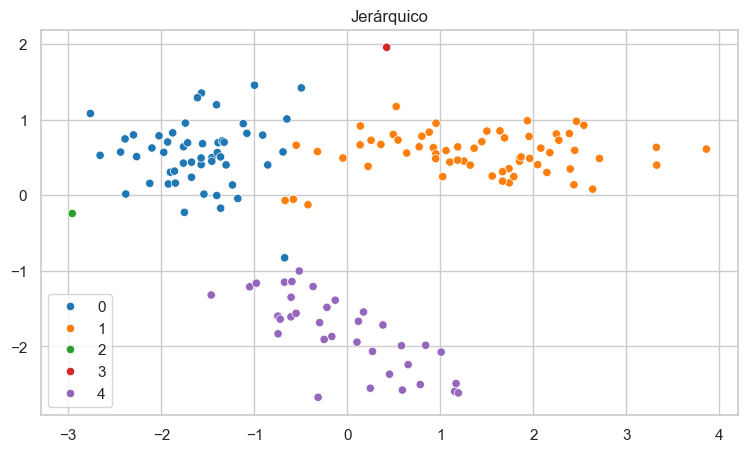

Comparación interna y provisional: no hay resultados de energización. La silueta de DBSCAN excluye ruido y no es directamente comparable a cobertura total. El jerárquico además muestra relaciones entre mezclas.


In [2]:
df=pd.read_csv('data/empowering_drinks.csv',sep='|')
display(df.head()); display(df.describe()); display(df.isna().sum())
sns.pairplot(df); plt.show()
sns.heatmap(df.corr(),annot=True,cmap='coolwarm'); plt.show()
# Retengo las cinco medidas: no hay identificadores y la estandarización iguala escalas.
features=df.columns.tolist()
scaler=StandardScaler(); X=scaler.fit_transform(df)
rows=[]; db_models={}
for min_samples in [4,6,10]:
    for eps in np.linspace(.15,2.5,60):
        m=DBSCAN(eps=float(eps),min_samples=min_samples).fit(X)
        lab=m.labels_; mask=lab!=-1; k=len(set(lab)-{-1})
        score=silhouette_score(X[mask],lab[mask]) if 1<k<mask.sum() else np.nan
        rows.append({'eps':eps,'min_samples':min_samples,'k':k,'ruido':1-mask.mean(),'silueta':score})
        db_models[(eps,min_samples)]=m
search=pd.DataFrame(rows)
eligible=search.query('3 <= k <= 5 and ruido <= 0.15').dropna()
if eligible.empty:
    eligible=search.query('3 <= k <= 5').dropna()
    print('No hay configuración con <=15% ruido: se informa la cobertura sin ocultarla.')
assert not eligible.empty
choice=eligible.sort_values(['silueta','ruido'],ascending=[False,True]).iloc[0]
db=db_models[(choice.eps,int(choice.min_samples))]
display(eligible.sort_values('silueta',ascending=False).head())
Z=linkage(X,method='average')
plt.figure(figsize=(12,5)); dendrogram(Z,truncate_mode='lastp',p=20); plt.show()
hier_models={k:AgglomerativeClustering(n_clusters=k,linkage='average').fit(X) for k in [3,4,5]}
hier_scores=pd.Series({k:silhouette_score(X,m.labels_) for k,m in hier_models.items()})
display(hier_scores.rename('silueta_jerarquico'))
hier=hier_models[int(hier_scores.idxmax())]
comparison=pd.DataFrame([
    {'modelo':'DBSCAN','k':int(choice.k),'silueta':choice.silueta,'cobertura':np.mean(db.labels_!=-1)},
    {'modelo':'Jerárquico','k':hier.n_clusters,'silueta':hier_scores.max(),'cobertura':1.0}])
display(comparison)
for name,labels in [('DBSCAN',db.labels_),('Jerárquico',hier.labels_)]:
    display(df.assign(cluster=labels).groupby('cluster').agg(['mean','count']))
    coords=PCA(2).fit_transform(X)
    sns.scatterplot(x=coords[:,0],y=coords[:,1],hue=labels,palette='tab10'); plt.title(name); plt.show()
print('Comparación interna y provisional: no hay resultados de energización. La silueta de DBSCAN excluye ruido y no es directamente comparable a cobertura total. El jerárquico además muestra relaciones entre mezclas.')

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [3]:
new=pd.read_csv('data/new_experiments.csv',sep='|')
assert new.columns.tolist()==features
X_new=scaler.transform(new)
# DBSCAN carece de predict: extensión inductiva por el core más cercano dentro de eps.
# No se reajusta el modelo ni se alteran los clusters iniciales.
assert len(db.core_sample_indices_)>0
nn=NearestNeighbors(n_neighbors=1).fit(db.components_)
def assign_dbscan(values):
    distances,indices=nn.kneighbors(values)
    return np.where(distances[:,0]<=db.eps,db.labels_[db.core_sample_indices_[indices[:,0]]],-1)
new_labels=assign_dbscan(X_new)
display(new.assign(cluster=new_labels))
# Extensión para comparar también el jerárquico: distancia media a miembros del grupo.
from sklearn.metrics import pairwise_distances
def assign_hier(values):
    distances=pairwise_distances(values,X)
    return np.column_stack([distances[:,hier.labels_==g].mean(axis=1) for g in range(hier.n_clusters)]).argmin(axis=1)
new_hier=assign_hier(X_new)
print('Asignación de muestras futuras mediante reglas explícitas, no predict nativo de estos algoritmos.')

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,cluster
0,1.481555,0.305159,1.366128,2.239039,0.731870,0
1,0.616869,0.890014,0.583034,0.312420,-0.665332,0
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,1
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,1
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,2


Asignación de muestras futuras mediante reglas explícitas, no predict nativo de estos algoritmos.


### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

In [4]:
truth=pd.read_csv('data/power_results.csv')['class'].to_numpy()
assert len(truth)==len(df)+len(new)
evaluation=[]
for name,labels in [('DBSCAN',np.r_[db.labels_,new_labels]),('Jerárquico',np.r_[hier.labels_,new_hier])]:
    mask=labels!=-1
    evaluation.append({'modelo':name,'ARI_total':adjusted_rand_score(truth,labels),
                       'NMI_total':normalized_mutual_info_score(truth,labels),'cobertura':mask.mean(),
                       'ARI_sin_ruido':adjusted_rand_score(truth[mask],labels[mask])})
    display(pd.crosstab(pd.Series(labels,name='cluster'),pd.Series(truth,name='energizacion')))
display(pd.DataFrame(evaluation))
print('ARI y NMI son invariantes al nombre del cluster. Las clases solo se usan ahora para evaluación externa, nunca para escoger features o hiperparámetros.')

energizacion,1,2,3
cluster,,,
-1,4,10,3
0,54,2,0
1,0,50,0
2,0,0,36


energizacion,1,2,3
cluster,,,
0,0,53,1
1,58,7,0
2,0,1,0
3,0,1,0
4,0,0,38


,modelo,ARI_total,NMI_total,cobertura,ARI_sin_ruido
0,DBSCAN,0.790268,0.773550,0.893082,0.953621
1,Jerárquico,0.824144,0.819455,1.000000,0.824144


ARI y NMI son invariantes al nombre del cluster. Las clases solo se usan ahora para evaluación externa, nunca para escoger features o hiperparámetros.


### Interpretación de los resultados obtenidos

DBSCAN separa tres perfiles: el grupo 0 tiene azúcar/cafeína/ácido cítrico altos; el 1, azúcar y taurina bajos; el 2, cafeína baja y taurina alta. Son niveles relativos: los datos incluyen valores negativos y parecen estar transformados, por lo que no deben interpretarse como gramos. El jerárquico obtiene tres grupos grandes y dos mezclas aisladas; sus cinco grupos no equivalen a cinco segmentos comerciales robustos. Los gráficos bidimensionales muestran las primeras dos PCs, pero las distancias se calculan con las cinco variables.

Con las pruebas externas, el ARI total favorece al jerárquico (0.824 frente a 0.790), mientras DBSCAN es más coherente en los casos que sí asigna (ARI sin ruido 0.954). Esa ventaja viene con menor cobertura: no se debe comparar la calidad excluyendo el coste de las anomalías. Las nuevas mezclas se asignan a 0,0,1,1,2,2 con la regla de proximidad a núcleos de DBSCAN.